# 📊 Data Science Project

![Data Science Project](plfs.jpeg)

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Importing Libraries

</h2>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from tabulate import tabulate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Loading Dataset

</h2>

In [2]:
df = pd.read_csv(r"C:\Users\itsvi\Downloads\Data Science\plfs_dataset.csv")

In [3]:
df.head()

,Age,Gender,Education,Experience_Years,Sector,Employment_Status
0,45,Female,Graduate,25,Healthcare,Employed
1,24,Female,Postgraduate,5,Retail,Employed
2,49,Male,Diploma,30,IT,Employed
3,28,Male,Postgraduate,10,IT,Employed
4,27,Female,Postgraduate,8,Education,Employed


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Checking Shape and Column

</h2>

In [4]:
df.shape

(2000, 6)

In [5]:
df.columns

Index(['Age', 'Gender', 'Education', 'Experience_Years', 'Sector',
       'Employment_Status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Gender             2000 non-null   object
 2   Education          2000 non-null   object
 3   Experience_Years   2000 non-null   int64 
 4   Sector             2000 non-null   object
 5   Employment_Status  2000 non-null   object
dtypes: int64(2), object(4)
memory usage: 93.9+ KB


In [7]:
df.describe()

,Age,Experience_Years
count,2000.000000,2000.000000
mean,38.579500,20.627500
std,12.065715,12.140446
min,18.000000,0.000000
25%,28.000000,10.000000
50%,38.000000,21.000000
75%,49.000000,31.000000
max,59.000000,43.000000


In [8]:
df.isnull().sum()

Age                  0
Gender               0
Education            0
Experience_Years     0
Sector               0
Employment_Status    0
dtype: int64

In [9]:
df = df.drop_duplicates()

In [10]:
datadict=pd.DataFrame(df.dtypes)
datadict['Missing value']=df.isna().sum()
datadict['N Unique']=df.nunique()
datadict['Count']=df.count()
datadict=datadict.rename(columns={0:'DataType'})
datadict

,DataType,Missing value,N Unique,Count
Age,int64,0,42,1830
Gender,object,0,2,1830
Education,object,0,5,1830
Experience_Years,int64,0,44,1830
Sector,object,0,5,1830
Employment_Status,object,0,2,1830


In [11]:
num_col=df.select_dtypes(include='number')
num_col

,Age,Experience_Years
0,45,25
1,24,5
2,49,30
3,28,10
4,27,8
...,...,...
1994,36,20
1996,27,9
1997,53,35
1998,26,8


In [12]:
df.groupby('Employment_Status')['Age'].mean()

Employment_Status
Employed      40.768894
Unemployed    22.183406
Name: Age, dtype: float64

In [13]:
df.groupby('Employment_Status')['Experience_Years'].mean()

Employment_Status
Employed      22.836352
Unemployed     4.061135
Name: Experience_Years, dtype: float64

In [14]:
pd.crosstab(
    df['Sector'],
    df['Employment_Status']
)

Employment_Status,Employed,Unemployed
Sector,,
Education,312,30
Healthcare,297,42
IT,344,56
Manufacturing,340,61
Retail,308,40


In [15]:
df.groupby('Sector')['Experience_Years'].mean()

Sector
Education        21.614035
Healthcare       20.917404
IT               19.792500
Manufacturing    19.553616
Retail           20.833333
Name: Experience_Years, dtype: float64

In [16]:
df.groupby('Sector')['Age'].mean()

Sector
Education        39.532164
Healthcare       38.876106
IT               37.772500
Manufacturing    37.568579
Retail           38.729885
Name: Age, dtype: float64

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">Data Visualization

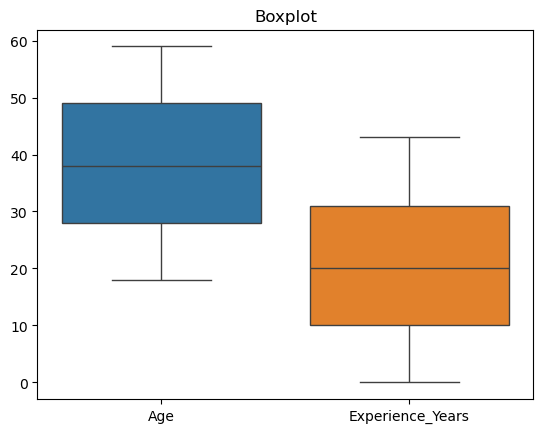

In [17]:
sns.boxplot(data=df[['Age','Experience_Years']])

plt.title("Boxplot")
plt.show()

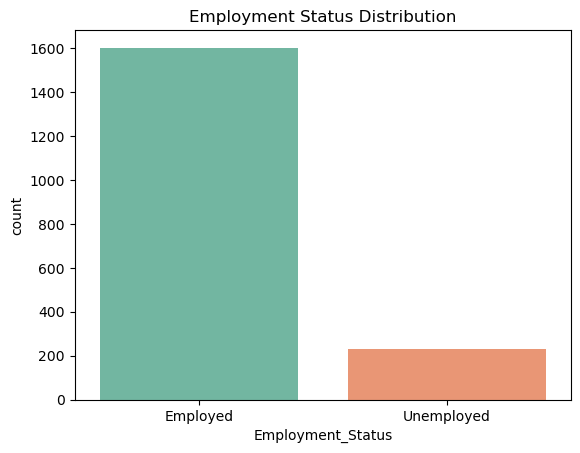

In [18]:
sns.countplot(
    x='Employment_Status',
    data=df,
    palette='Set2'
)

plt.title("Employment Status Distribution")
plt.show()

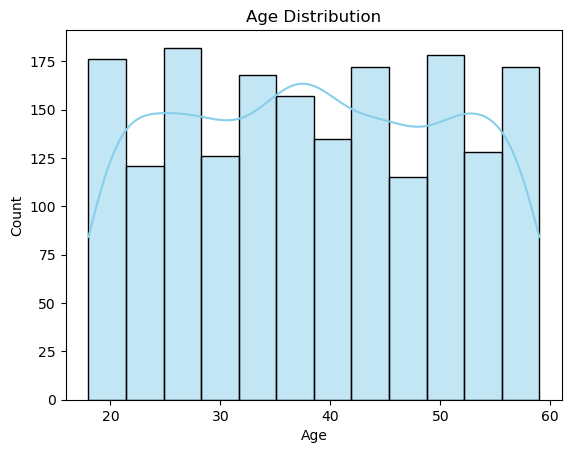

In [19]:
sns.histplot(
    df['Age'],
    kde=True,
    color='skyblue'
)

plt.title("Age Distribution")
plt.show()

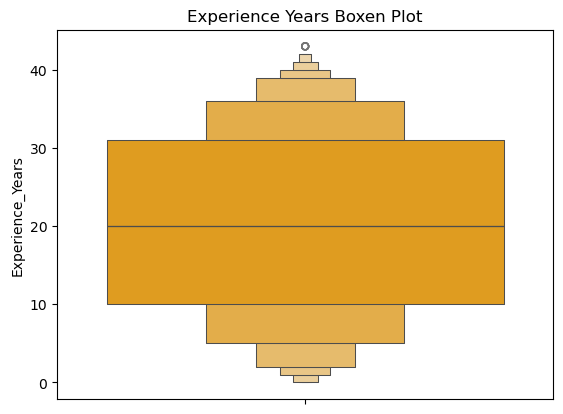

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxenplot(
    y=df['Experience_Years'],
    color='orange'
)

plt.title("Experience Years Boxen Plot")
plt.show()

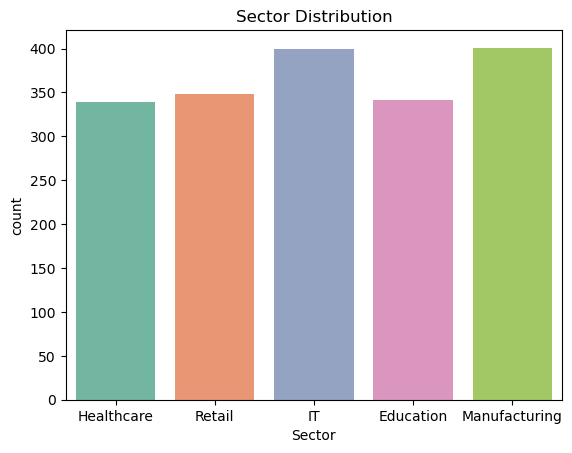

In [21]:
sns.countplot(
    x='Sector',
    data=df,
    palette='Set2'
)

plt.title("Sector Distribution")
plt.show()

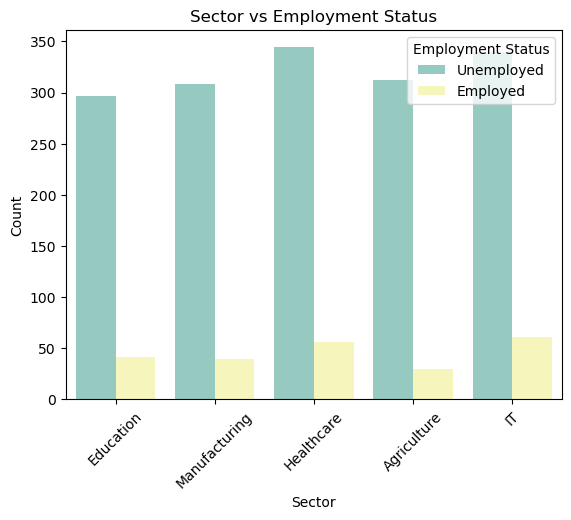

In [65]:
sector_names = {
    0:'Agriculture',
    1:'Education',
    2:'Healthcare',
    3:'IT',
    4:'Manufacturing'
}

df['Sector_Name'] = df['Sector'].map(sector_names)
ax = sns.countplot(
    x='Sector_Name',
    hue='Employment_Status',
    data=df,
    palette='Set3'
)

ax.legend(
    title='Employment Status',
    labels=['Unemployed','Employed']
)

plt.title("Sector vs Employment Status")
plt.xlabel("Sector")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

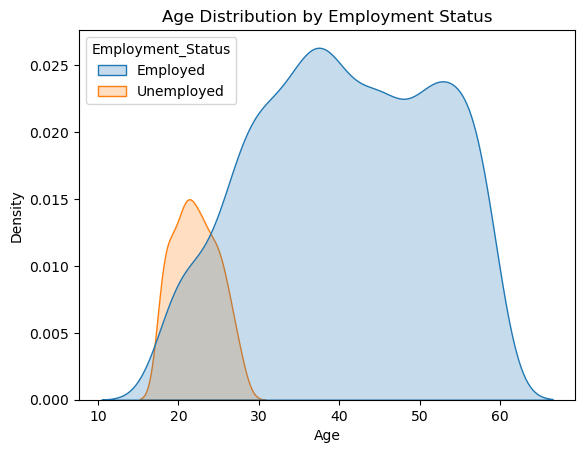

In [23]:
sns.kdeplot(
    data=df,
    x='Age',
    hue='Employment_Status',
    fill=True
)

plt.title("Age Distribution by Employment Status")
plt.show()

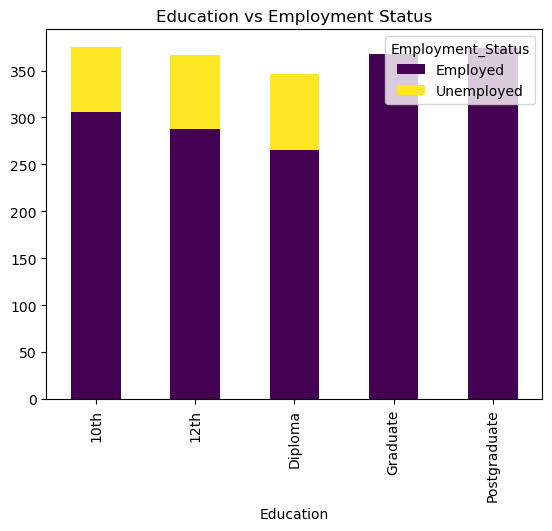

In [24]:
pd.crosstab(
    df['Education'],
    df['Employment_Status']
).plot(
    kind='bar',
    stacked=True,
    colormap='viridis'
)

plt.title("Education vs Employment Status")
plt.show()

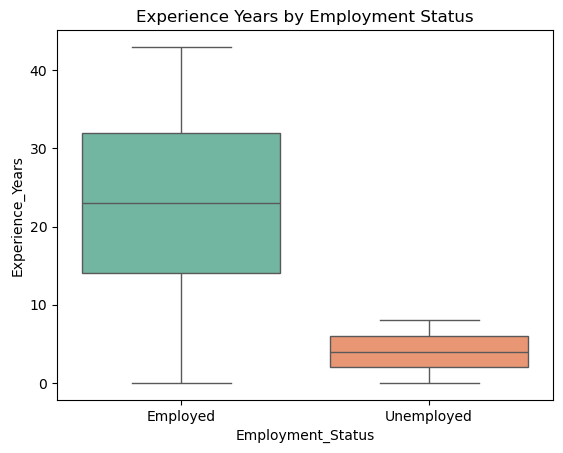

In [25]:
sns.boxplot(
    x='Employment_Status',
    y='Experience_Years',
    data=df,
    palette='Set2'
)

plt.title("Experience Years by Employment Status")
plt.show()

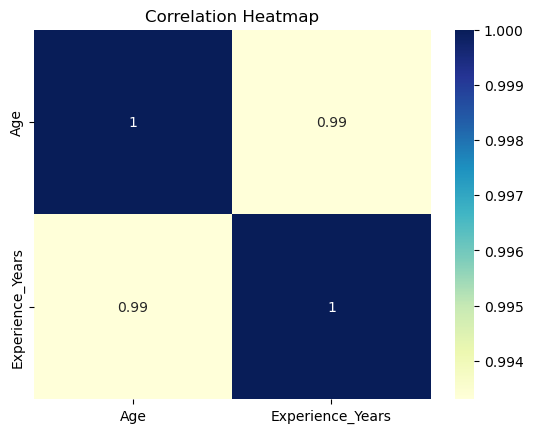

In [26]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='YlGnBu'
)

plt.title("Correlation Heatmap")
plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Encoding


In [27]:
le = LabelEncoder()

cols = ['Gender', 'Education', 'Sector', 'Employment_Status']

for i in cols:
    df[i] = le.fit_transform(df[i])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1830 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1830 non-null   int64 
 1   Gender             1830 non-null   int64 
 2   Education          1830 non-null   int64 
 3   Experience_Years   1830 non-null   int64 
 4   Sector             1830 non-null   int64 
 5   Employment_Status  1830 non-null   int64 
 6   Sector_Name        0 non-null      object
dtypes: int64(6), object(1)
memory usage: 114.4+ KB


In [28]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)
df.drop('Sector_Name', axis=1, inplace=True)

Index(['Sector_Name'], dtype='object')


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Splitting Features and Target

</h2>

In [29]:
X = df.drop('Employment_Status', axis=1)
y = df['Employment_Status']

In [30]:
df['Employment_Status'].value_counts()

Employment_Status
0    1601
1     229
Name: count, dtype: int64

In [31]:
X.dtypes

Age                 int64
Gender              int64
Education           int64
Experience_Years    int64
Sector              int64
dtype: object

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Scaling

</h2>

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Train-Test Split

</h2>

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Model Building

</h2>

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Logistic Regression

</h2>

In [36]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_smote, y_train_smote)

y_pred1 = model1.predict(X_test)

acc1 = accuracy_score(y_test, y_pred1)
print("Logistic Regression:", acc1)

Logistic Regression: 0.9262295081967213


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Random Forest Classifier

</h2>

In [37]:
model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test,y_pred2)
acc2

1.0

In [39]:
accuracy = accuracy_score(y_test, y_pred2)
print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
SVR

</h2>

In [40]:
model4 = SVC(kernel='linear')

model4.fit(X_train_smote, y_train_smote)

y_pred4 = model4.predict(X_test)

acc4 = accuracy_score(y_test, y_pred4)
print("SVM Linear:", acc4)

SVM Linear: 0.9207650273224044


In [41]:
model5 = SVC(kernel='rbf')

model5.fit(X_train_smote, y_train_smote)

y_pred5 = model5.predict(X_test)

acc5 = accuracy_score(y_test, y_pred5)
print("SVM RBF:", acc5)

SVM RBF: 0.9808743169398907


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
KNN

</h2>

In [42]:
metric_k = []

neighbors = np.arange(3,15)

for k in neighbors:
    model = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    metric_k.append(acc)

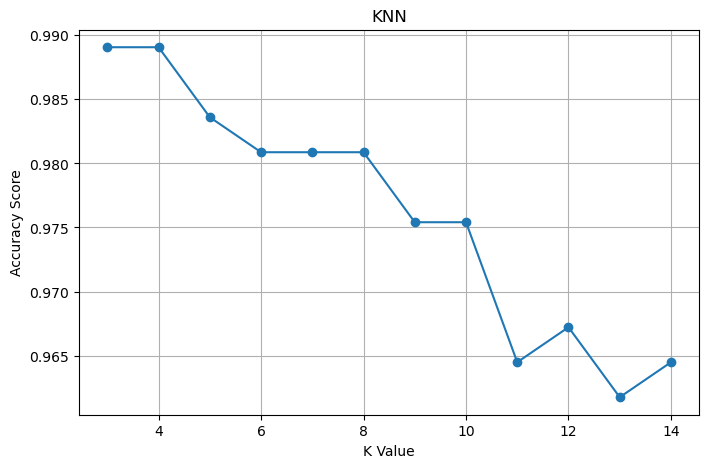

In [66]:
plt.figure(figsize=(8,5))

plt.plot(neighbors, metric_k, 'o-')

plt.xlabel('K Value')
plt.ylabel('Accuracy Score')
plt.title('KNN')

plt.grid(True)

plt.show()

In [44]:
best_k = neighbors[np.argmax(metric_k)]

print("Best K Value:", best_k)
print("Best Accuracy:", max(metric_k))

Best K Value: 3
Best Accuracy: 0.9890710382513661


In [45]:
model_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean'
)

model_knn.fit(X_train_smote, y_train_smote)

y_pred6 = model_knn.predict(X_test)

acc6 = accuracy_score(y_test, y_pred6)

print("Final Accuracy:", acc6)

Final Accuracy: 0.9890710382513661


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
XGB Classifier

</h2>

In [46]:
model7 = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model7.fit(X_train_smote, y_train_smote)

y_pred7 = model7.predict(X_test)

acc7 = accuracy_score(y_test, y_pred7)

print("XGBoost Accuracy:", acc7)

XGBoost Accuracy: 1.0


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
LGBM Classifier

</h2>

In [47]:
model9 = lgb.LGBMClassifier()

model9.fit(X_train, y_train)

y_pred9 = model9.predict(X_test)

acc9 = accuracy_score(y_test, y_pred9)

print("LightGBM Accuracy:", acc9)

[LightGBM] [Info] Number of positive: 183, number of negative: 1281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 103
[LightGBM] [Info] Number of data points in the train set: 1464, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.125000 -> initscore=-1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Tabulate

</h2>

In [48]:
table = [
    ['Logistic Regression', acc1],
    ['Random Forest', acc2],
    ['SVM Linear', acc4],
    ['SVM RBF', acc5],
    ['KNN',acc6],
    ['XGBoost', acc7],
    ['LightGBM', acc9]
]

print(tabulate(
    table,
    headers=['Model', 'Accuracy'],
    tablefmt='fancy_grid'
))

╒═════════════════════╤════════════╕
│ Model               │   Accuracy │
╞═════════════════════╪════════════╡
│ Logistic Regression │   0.92623  │
├─────────────────────┼────────────┤
│ Random Forest       │   1        │
├─────────────────────┼────────────┤
│ SVM Linear          │   0.920765 │
├─────────────────────┼────────────┤
│ SVM RBF             │   0.980874 │
├─────────────────────┼────────────┤
│ KNN                 │   0.989071 │
├─────────────────────┼────────────┤
│ XGBoost             │   1        │
├─────────────────────┼────────────┤
│ LightGBM            │   1        │
╘═════════════════════╧════════════╛


In [49]:
models = [
    'Logistic Regression', 
    'Random Forest',  
    'SVM Linear', 
    'SVM RBF', 
    'KNN',
    'XGBoost', 
    'LightGBM', 
]

accuracy = [
    acc1,
    acc2,
    acc4,
    acc5,
    acc6,
    acc7,
    acc9
]

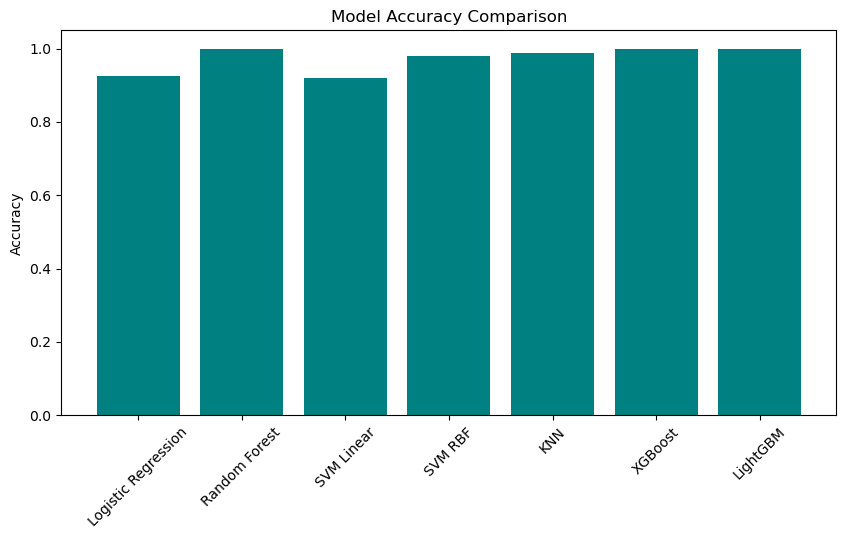

In [50]:
plt.figure(figsize=(10,5))

plt.bar(
    models,
    accuracy,
    color='teal'
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Hyperparameter Tuning

</h2>

In [51]:
model_grid = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

grid_search = GridSearchCV(
    model_grid,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Score: 1.0


In [52]:
model = XGBClassifier(
   learning_rate= 0.01,
    max_depth= 3,
    n_estimators=100,
    eval_metric='logloss'
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 1.0


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Feature Importance

</h2>

In [53]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
3  Experience_Years    0.811502
2         Education    0.188498
0               Age    0.000000
1            Gender    0.000000
4            Sector    0.000000


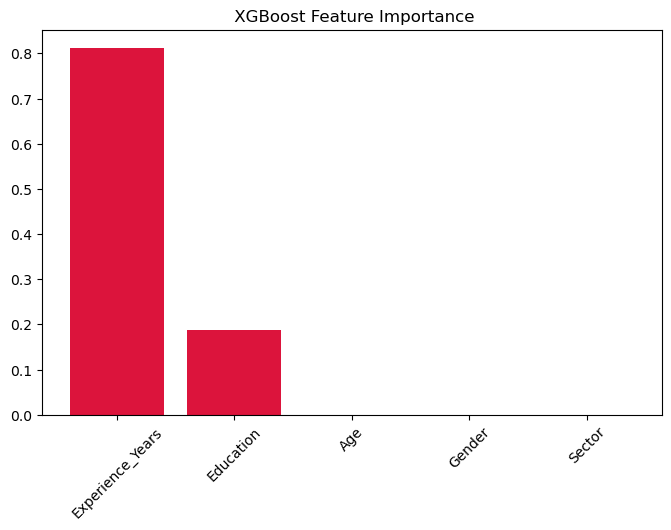

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance'],
    color='crimson'
)

plt.xticks(rotation=45)
plt.title(" XGBoost Feature Importance")

plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Model Evaluation

</h2>

In [55]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [56]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0


In [57]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 1.0


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
ROC Curve

</h2>

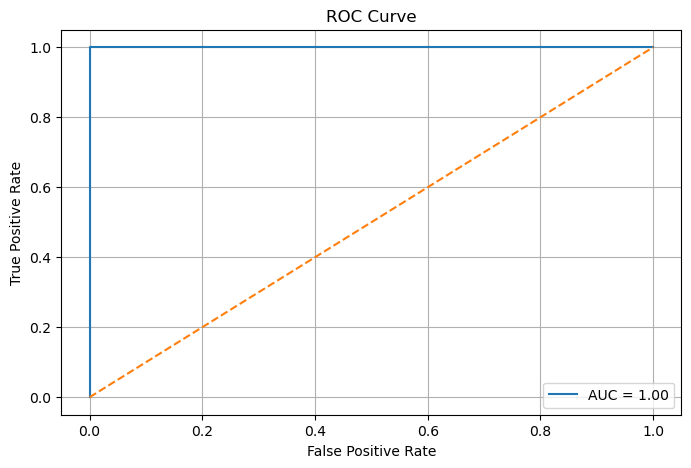

In [58]:
y_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Confusion Matrix

</h2>

In [59]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[320   0]
 [  0  46]]


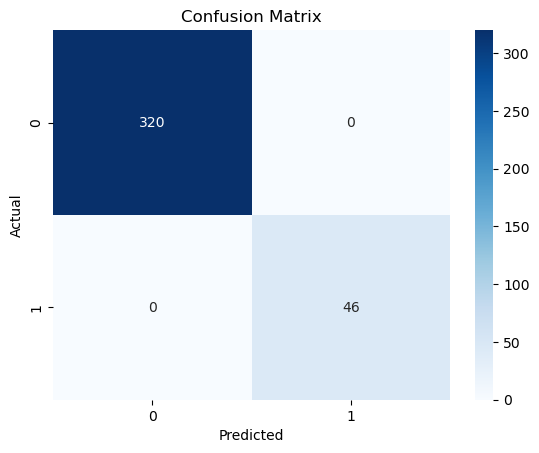

In [60]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Classification Report

</h2>

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00        46

    accuracy                           1.00       366
   macro avg       1.00      1.00      1.00       366
weighted avg       1.00      1.00      1.00       366



In [62]:
joblib.dump(model, "employment_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [63]:
import streamlit as st

st.title("💼 Employment Status Prediction System")

2026-06-27 10:14:19.339 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 10:14:22.284 
  command:

    streamlit run C:\Users\itsvi\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-27 10:14:22.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-27 10:14:22.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [64]:
import os
print(os.listdir())

['.ipynb_checkpoints', '07.02.26_All India & Regional Demands.xls', '12_Student_Performance_Predication.pdf', 'Actual_vs_Predicted.csv', 'Agglomerative mall customers.ipynb', 'ai_vs_human_content_v2_20000.csv', 'app.py', 'apples.zip', 'appp.py', 'areas.csv', 'beer-servings (1).csv', 'CALIFORNIA HOUSING TEST.ipynb', 'candy-data.csv', 'catboost_info', 'climate.ipynb', 'CNN N.ipynb', 'CNN2 N.ipynb', 'complete_dataset.csv', 'Country-data.csv', 'country.ipynb', 'datascience_gtec.pdf', 'Developer Stress.pdf', 'developer_stress.csv', 'electricity demand forecasting.ipynb', 'electricity demand.docx', 'electricity demand.ipynb', 'electricity demand.pdf', 'electricity demand.R', 'electricity demand.sql', 'electricity demand.twb', 'electricity demandd.sql', 'electricity.ipynb', 'employee_salary_dataset.csv', 'employment_model.pkl', 'EU AI Act Risk Register.ipynb', 'eu_ai_act_risk_register_2026.csv', 'Fake.csv', 'fertility.csv', 'fertility.ipynb', 'Fish.csv', 'fish.ipynb', 'ftest oneway jee.ipynb'